# PE-AV Embedding Analysis: RDMs and Single vs Joint Modality

Load PE-AV embeddings, compute representational discosine_similarity matrices (RDMs), and compare single vs joint modality embeddings for audio/video.

In [10]:
from pathlib import Path
from typing import List, Tuple, Dict, Any
from scipy.stats import gamma
from typing import Tuple
import numpy as np
from scipy import stats
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist
import pandas as pd
timing_df = pd.read_csv("/home/amin/Research/Representation/Movie/data/Setareh/Data/movie_timing.csv")

# Configuration
PEAV_RUNS = [
    {
        "label": "pe-av-small-16-frame",
        "model_name": "PE-AV Small-16-frame",
        "emb_dir": Path("/home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame"),
    },
    {
        "label": "pe-av-large-16-frame",
        "model_name": "PE-AV Large-16-frame",
        "emb_dir": Path("/home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large-16-frame"),
    },
        {
        "label": "pe-av-base-16-frame",
        "model_name": "PE-AV Base-16-frame",
        "emb_dir": Path("/home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base-16-frame"),
    },
        {
        "label": "pe-av-small",
        "model_name": "PE-AV Small",
        "emb_dir": Path("/home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small"),
    },
        {
        "label": "pe-av-base",
        "model_name": "PE-AV Base",
        "emb_dir": Path("/home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base"),
    },
        {
        "label": "pe-av-large",
        "model_name": "PE-AV Large",
        "emb_dir": Path("/home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large"),
    }
]

ALPHA = 0.05

## Core Functions

In [11]:
def load_modality_embeddings(emb_dir: Path) -> Tuple[np.ndarray, np.ndarray]:
    """Load audio and video and joint embeddings from NPZ file."""
    emb_dir = emb_dir.expanduser().resolve()
    if not emb_dir.exists():
        raise FileNotFoundError(f"Missing embeddings directory: {emb_dir}")
    
    npz_files = list(emb_dir.glob("*.npz"))
    if not npz_files:
        raise FileNotFoundError(f"No .npz files found in {emb_dir}")
    
    npz_file = npz_files[0]
    print(f"Loading: {npz_file.name}")
    data = np.load(npz_file)
    
    if "audio" not in data or "video" not in data:
        raise KeyError("NPZ must contain 'audio' and 'video' arrays")
    
    audio = data["audio"]
    video = data["video"]
    joint = data["av"]
    if (audio.shape[0] != video.shape[0]) | (audio.shape[0] != joint.shape[0]):
        raise ValueError(
            f"Segment count mismatch: audio={audio.shape[0]} video={video.shape[0]}"
        )
    
    print(f"  Audio shape: {audio.shape}, Video shape: {video.shape}, joint shape: {audio.shape}")
    return audio, video, joint


def plot_av_similarity_heatmap(
    sim: np.ndarray,
    out_path: Path,
    title: str,
    vmin: float = None,
    vmax: float = None,
    figsize: Tuple[int, int] = (6, 5),
) -> None:
    """Plot audio-video cross-similarity heatmap."""
    fig, ax = plt.subplots(figsize=figsize)
    
    if vmin is None:
        vmin = np.nanmin(sim)
    if vmax is None:
        vmax = np.nanmax(sim)
    
    im = ax.imshow(sim, origin="upper", cmap="coolwarm", vmin=vmin, vmax=vmax)
    
    cbar = fig.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label("Cosine similarity", fontsize=10)
    
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Video segment index", fontsize=10)
    ax.set_ylabel("Audio segment index", fontsize=10)
    
    fig.tight_layout()
    if out_path is not None:
        out_path = out_path.expanduser().resolve()
        out_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {out_path}")
    plt.show()
    plt.close(fig)


def compute_diag_stats(sim: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute diagonal vs off-diagonal statistics."""
    diag = np.diag(sim)
    
    # Mask diagonal to compute off-diagonal stats
    mask = ~np.eye(sim.shape[0], dtype=bool)
    off_mean = np.array([sim[i, mask[i]].mean() for i in range(sim.shape[0])])
    off_se = np.array([stats.sem(sim[i, mask[i]]) for i in range(sim.shape[0])])
    
    return diag, off_mean, off_se


def plot_diag_stats(
    diag: np.ndarray,
    off_mean: np.ndarray,
    off_se: np.ndarray,
    sig_indices: List[int],
    out_path: Path,
    title: str,
    alpha: float,
):
    """Plot diagonal vs off-diagonal with optional significance markers."""
    x = np.arange(len(diag))
    fig, ax = plt.subplots(figsize=(10, 4))
    
    ax.plot(x, diag, label="Diagonal (same segment)", color="C0", linewidth=1.5)
    ax.plot(x, off_mean, label="Off-diagonal mean", color="C1", linewidth=1.5)
    ax.fill_between(x, off_mean - off_se, off_mean + off_se, 
                     color="C1", alpha=0.3, label="Off-diagonal ±1 SE")
    
    if sig_indices:
        ax.scatter(sig_indices, diag[sig_indices], marker="*", 
                   color="red", s=150, zorder=3, edgecolor="black",
                   label=f"Significant (p < {alpha})")
    
    ax.set_xlabel("Segment index", fontsize=11)
    ax.set_ylabel("Cosine similarity", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {out_path}")


def find_significant_segments(sim: np.ndarray, alpha: float = 0.05) -> List[int]:
    """Find segments where diagonal > off-diagonal (one-sided t-test)."""
    n = sim.shape[0]
    sig_indices = []
    
    for i in range(n):
        diag_val = sim[i, i]
        off_vals = np.concatenate([sim[i, :i], sim[i, i+1:]])
        
        if len(off_vals) == 0:
            continue
        
        # One-sided t-test: H1: diag_val > mean(off_vals)
        t_stat, p_val = stats.ttest_1samp(off_vals, diag_val, alternative='less')
        
        if p_val < alpha and diag_val > off_vals.mean():
            sig_indices.append(i)
    
    return sig_indices


def spm_hrf(tr, oversampling=16):
    dt = tr / oversampling
    u = np.arange(0, 32, dt) - dt/2
    h = (6 * gamma.pdf(u, 6, loc=0, scale=1) - 
         1/6 * gamma.pdf(u, 16, loc=0, scale=1))
    return h / np.sum(h)


def process_model_by_video(model_embeddings, timing_df, tr=2.0, bin_sec=2.0):
    """
    Convolves each video segment INDEPENDENTLY to prevent bleeding across cuts.
    """
    import numpy as np
    from scipy.stats import zscore
    
    # 1. Define HRF
    hrf = spm_hrf(tr, oversampling=1)
    
    # 2. Get bin counts per video (same logic as  fMRI processing)
    # This tells us how to slice the big (1581, 1024) matrix
    video_bin_counts = (timing_df['duration_sec'] / bin_sec).astype(int).values
    
    # Check if total matches
    if np.sum(video_bin_counts) != model_embeddings.shape[0]:
        print(f"Warning: Model length ({model_embeddings.shape[0]}) != Timing sum ({np.sum(video_bin_counts)})")
    else:
        print(f"Model length matches timing sum: {model_embeddings.shape[0]} bins")
    
    convolved_segments = []
    current_idx = 0
    
    print("Convolving videos separately...")
    
    # 3. Loop through each video
    for n, n_bins in enumerate(video_bin_counts):
        # Extract ONE video
        video_data = model_embeddings[current_idx : current_idx + n_bins, :]
        
        # Convolve just this video
        # (The HRF tail will fall off the end, which is CORRECT because the next video is 30s later)
        video_conv = np.zeros_like(video_data)
        for i in range(video_data.shape[1]):
            conv = np.convolve(video_data[:, i], hrf, mode='full')
            video_conv[:, i] = conv[:n_bins] # Trim to original length
            
        convolved_segments.append(video_conv)
        print(f" \n Video {n+1}: {n_bins} bins convolved")
        current_idx += n_bins
        
    # 4. Stitch them back together
    full_convolved_model = np.concatenate(convolved_segments, axis=0)
    
    # 5. NOW Z-score the whole thing (Global Normalization is usually fine/better)
    full_model_norm = zscore(full_convolved_model, axis=0)
    
    return full_model_norm

def compute_rdm(embeddings: np.ndarray, metric: str = "correlation") -> np.ndarray:
    """Compute representational dissimilarity matrix using scipy.spatial.distance.pdist."""
    if metric not in ["correlation", "cosine"]:
        raise ValueError(f"Unknown metric: {metric}")
    s = embeddings.shape
    if len(s) == 1:
        embeddings = embeddings.reshape(-1, 1)
    clean_embeddings = process_model_by_video(embeddings, timing_df)
    rdm = squareform(pdist(clean_embeddings, metric=metric))
    return rdm


def plot_rdm(
    rdm: np.ndarray,
    out_path: Path,
    title: str,
    metric: str = "correlation",
    figsize: Tuple[int, int] = (6, 5),
) -> None:
    """Plot RDM heatmap."""
    fig, ax = plt.subplots(figsize=figsize)
    
    im = ax.imshow(rdm, origin="upper", cmap="coolwarm")
    
    cbar = fig.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label(f"Dissimilarity ({metric})", fontsize=10)
    
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Segment index", fontsize=10)
    ax.set_ylabel("Segment index", fontsize=10)
    
    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {out_path}")

## Similarity and RDM Analysis


Processing: PE-AV Small-16-frame
Loading: pe-av-small-16-frame_2s.npz
  Audio shape: (1581, 1024), Video shape: (1581, 1024), joint shape: (1581, 1024)

Audio embeddings: shape=(1581, 1024), mean=-0.003, std=0.078
Video embeddings: shape=(1581, 1024), mean=0.001, std=0.101
Joint embeddings: shape=(1581, 1024), mean=-0.000, std=0.094

[1/5] Computing audio-video cosine similarity...
Similarity matrix: shape=(1581, 1581), min=-0.160, max=0.205, mean=0.023
Pearson Correlation distance matrix: shape=(1581, 1581), min=0.795, max=1.160, mean=0.977

[2/5] Plotting similarity and correlation distance heatmaps...
Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_av_similarity.png


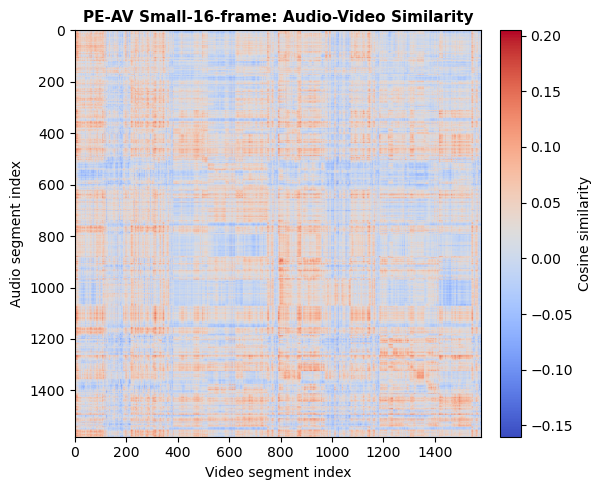

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_av_similarity.png


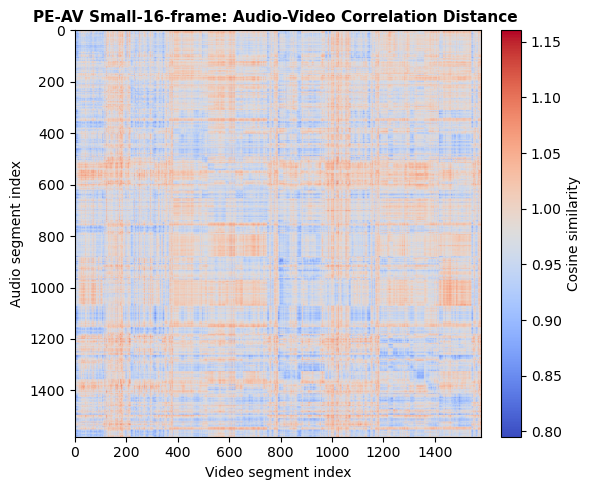


[3/5] Computing diagonal vs off-diagonal statistics...
Diagonal: mean=0.061, std=0.035
Off-diagonal: mean=0.023, std=0.020


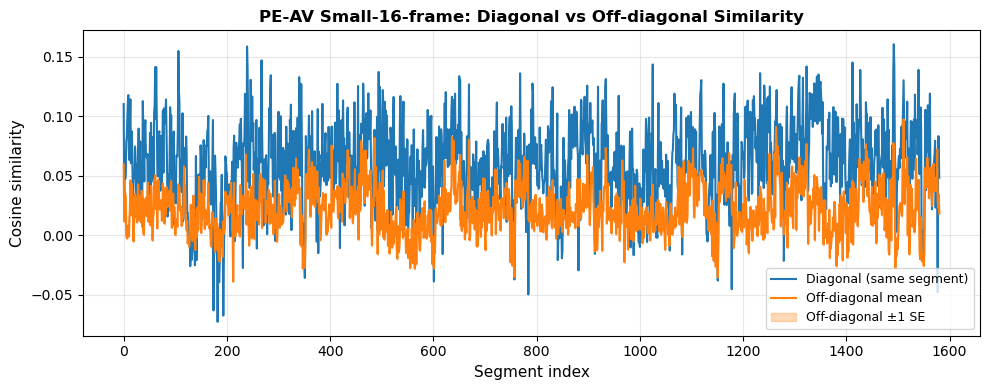

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_diag_analysis.png

[4/5] Finding significant segments (alpha=0.05)...


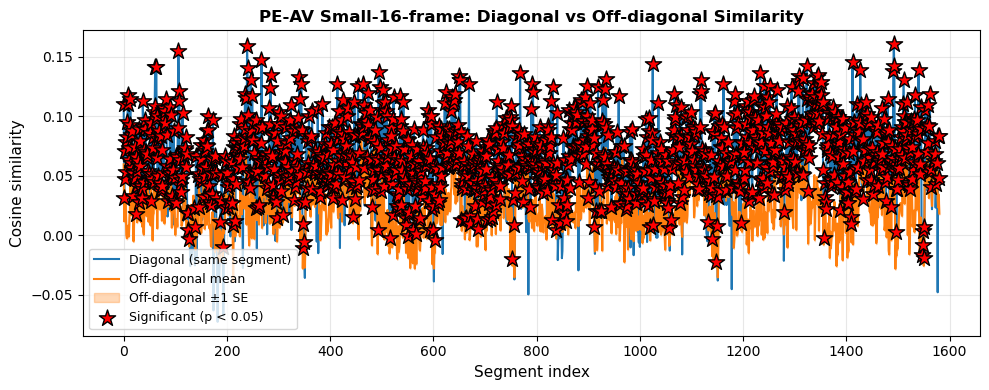

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_diag_analysis.png
Saved significant segments to: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_significant_segments.npy and /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_significant_segments.txt

[5/5] Computing RDMs...
Model length matches timing sum: 1581 bins
Convolving videos separately...
 
 Video 1: 106 bins convolved
 
 Video 2: 110 bins convolved
 
 Video 3: 93 bins convolved
 
 Video 4: 31 bins convolved
 
 Video 5: 41 bins convolved
 
 Video 6: 113 bins convolved
 
 Video 7: 129 bins convolved
 
 Video 8: 124 bins convolved
 
 Video 9: 41 bins convolved
 
 Video 10: 90 bins convolved
 
 Video 11: 92 bins convolved
 
 Video 12: 101 bins convolved
 
 Video 13: 70 bins convolved
 
 Video 14: 41 bins convolved
 
 Video 15: 116 bins convolved
 
 

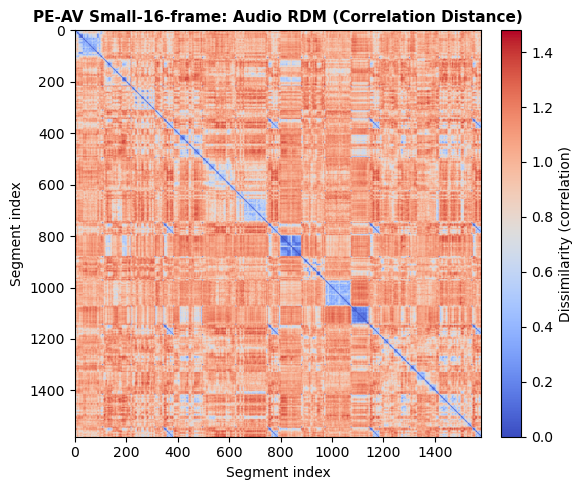

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_rdm_audio.png


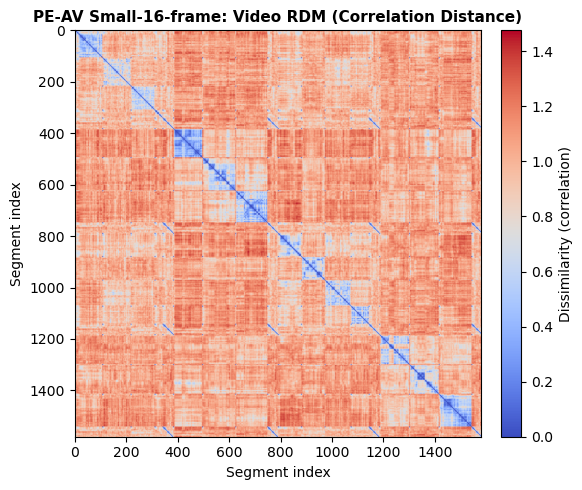

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_rdm_video.png


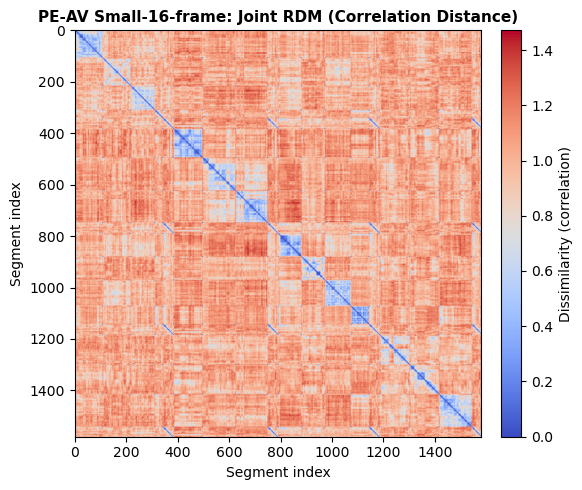

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame_rdm_video.png

RESULTS SUMMARY FOR PE-AV Small-16-frame
Total segments: 1581
Significant segments: 1404 (88.8%)
Mean diagonal similarity: 0.061 ± 0.035
Mean off-diagonal similarity: 0.023 ± 0.020
Diagonal - Off-diagonal: 0.038

All outputs saved to: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame


Processing: PE-AV Large-16-frame
Loading: pe-av-large-16-frame.npz
  Audio shape: (1581, 1024), Video shape: (1581, 1024), joint shape: (1581, 1024)

Audio embeddings: shape=(1581, 1024), mean=0.003, std=0.079
Video embeddings: shape=(1581, 1024), mean=0.001, std=0.116
Joint embeddings: shape=(1581, 1024), mean=0.004, std=0.107

[1/5] Computing audio-video cosine similarity...
Similarity matrix: shape=(1581, 1581), min=-0.159, max=0.227, mean=0.010
Pearson Correlation distance matrix: shape=(1581, 1581), min=0.774, max=1.159, mean=0.991

[2

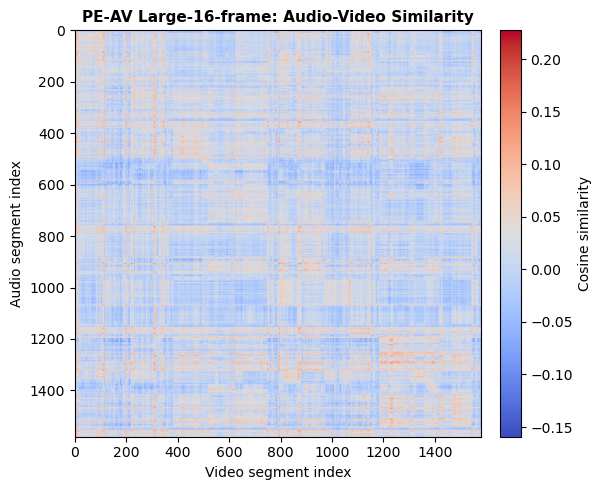

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large-16-frame/pe-av-large-16-frame_av_similarity.png


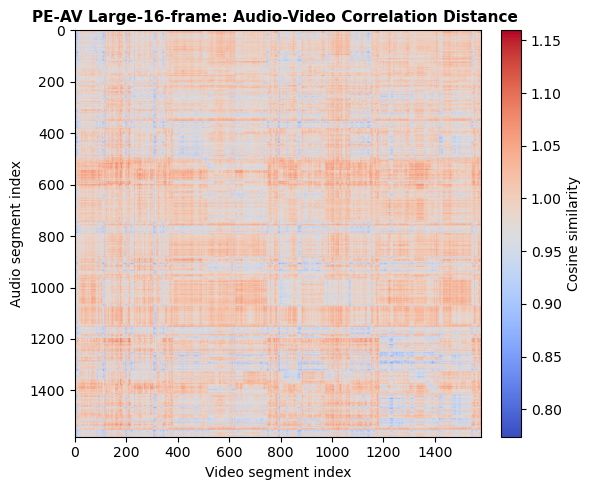


[3/5] Computing diagonal vs off-diagonal statistics...
Diagonal: mean=0.043, std=0.034
Off-diagonal: mean=0.010, std=0.021


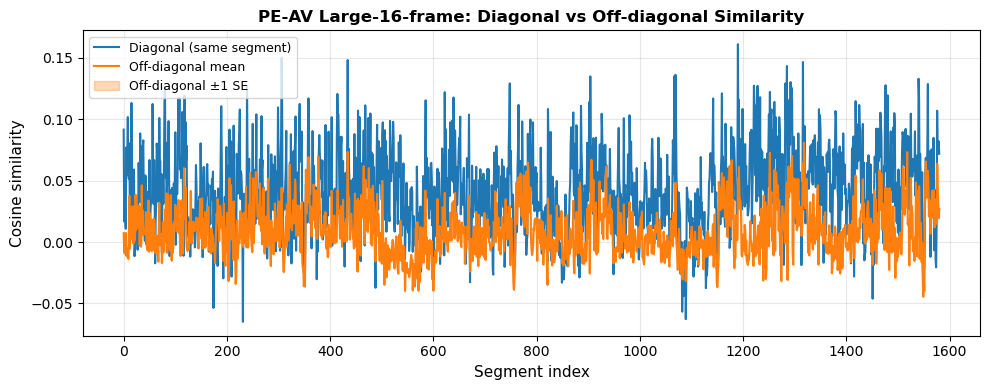

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large-16-frame/pe-av-large-16-frame_diag_analysis.png

[4/5] Finding significant segments (alpha=0.05)...


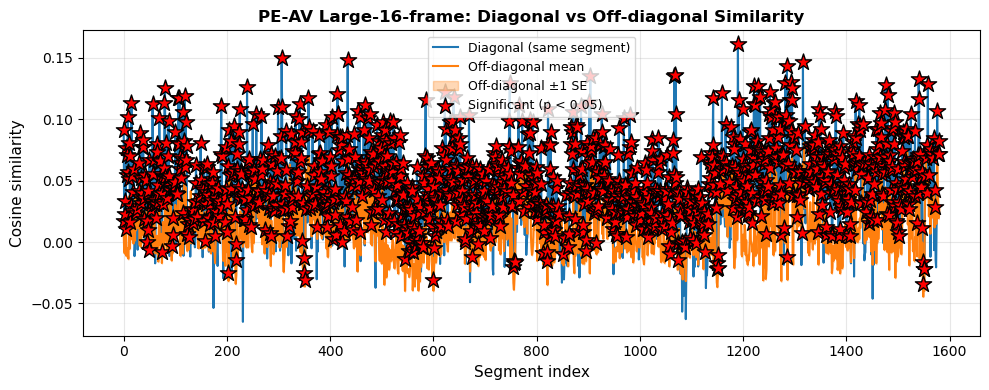

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large-16-frame/pe-av-large-16-frame_diag_analysis.png
Saved significant segments to: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large-16-frame/pe-av-large-16-frame_significant_segments.npy and /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large-16-frame/pe-av-large-16-frame_significant_segments.txt

[5/5] Computing RDMs...
Model length matches timing sum: 1581 bins
Convolving videos separately...
 
 Video 1: 106 bins convolved
 
 Video 2: 110 bins convolved
 
 Video 3: 93 bins convolved
 
 Video 4: 31 bins convolved
 
 Video 5: 41 bins convolved
 
 Video 6: 113 bins convolved
 
 Video 7: 129 bins convolved
 
 Video 8: 124 bins convolved
 
 Video 9: 41 bins convolved
 
 Video 10: 90 bins convolved
 
 Video 11: 92 bins convolved
 
 Video 12: 101 bins convolved
 
 Video 13: 70 bins convolved
 
 Video 14: 41 bins convolved
 
 Video 15: 116 bins convolved
 
 

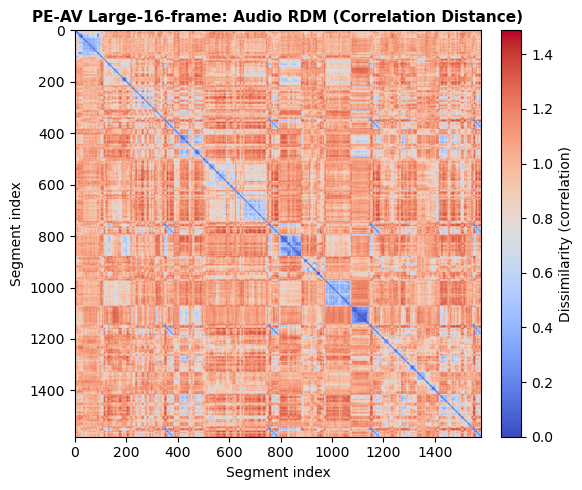

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large-16-frame/pe-av-large-16-frame_rdm_audio.png


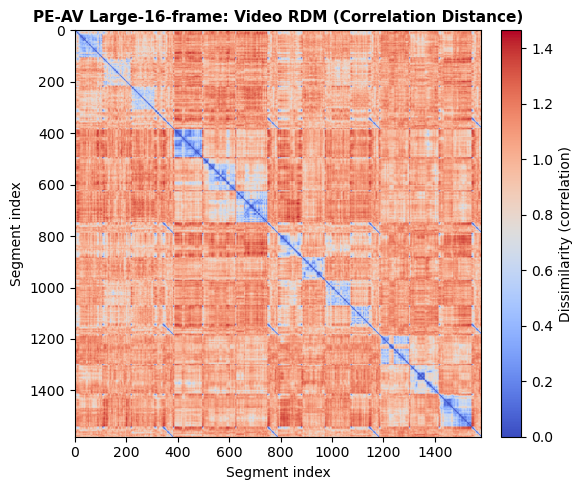

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large-16-frame/pe-av-large-16-frame_rdm_video.png


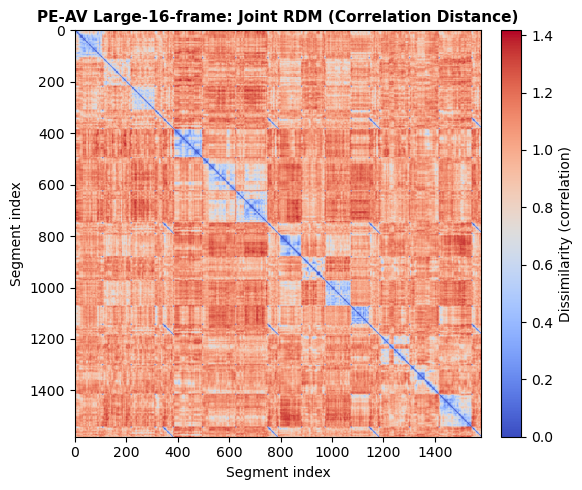

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large-16-frame/pe-av-large-16-frame_rdm_video.png

RESULTS SUMMARY FOR PE-AV Large-16-frame
Total segments: 1581
Significant segments: 1351 (85.5%)
Mean diagonal similarity: 0.043 ± 0.034
Mean off-diagonal similarity: 0.010 ± 0.021
Diagonal - Off-diagonal: 0.033

All outputs saved to: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large-16-frame


Processing: PE-AV Base-16-frame
Loading: pe-av-base-16-frame.npz
  Audio shape: (1581, 1024), Video shape: (1581, 1024), joint shape: (1581, 1024)

Audio embeddings: shape=(1581, 1024), mean=-0.001, std=0.078
Video embeddings: shape=(1581, 1024), mean=-0.006, std=0.107
Joint embeddings: shape=(1581, 1024), mean=-0.005, std=0.102

[1/5] Computing audio-video cosine similarity...
Similarity matrix: shape=(1581, 1581), min=-0.152, max=0.244, mean=0.014
Pearson Correlation distance matrix: shape=(1581, 1581), min=0.757, max=1.153, mean=0.987

[

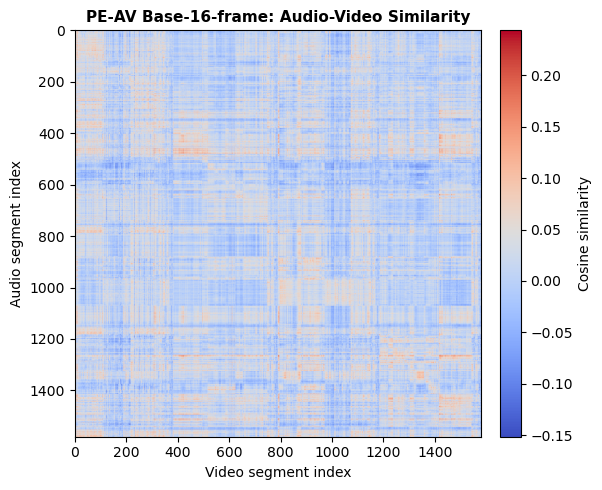

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base-16-frame/pe-av-base-16-frame_av_similarity.png


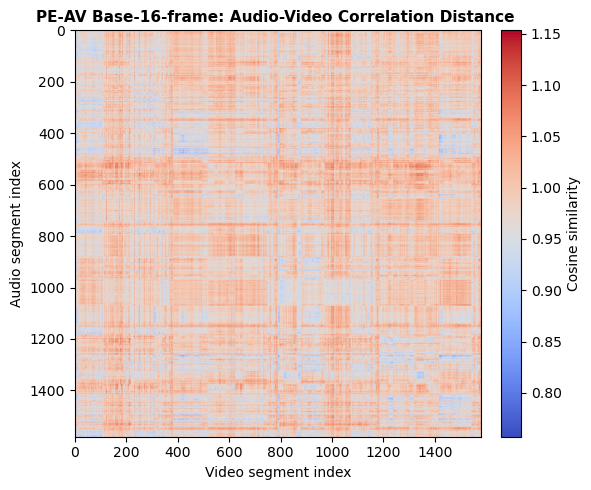


[3/5] Computing diagonal vs off-diagonal statistics...
Diagonal: mean=0.051, std=0.035
Off-diagonal: mean=0.014, std=0.019


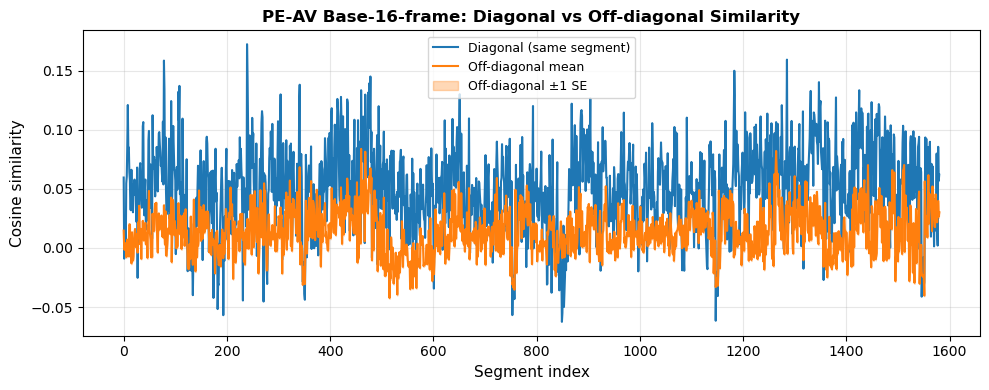

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base-16-frame/pe-av-base-16-frame_diag_analysis.png

[4/5] Finding significant segments (alpha=0.05)...


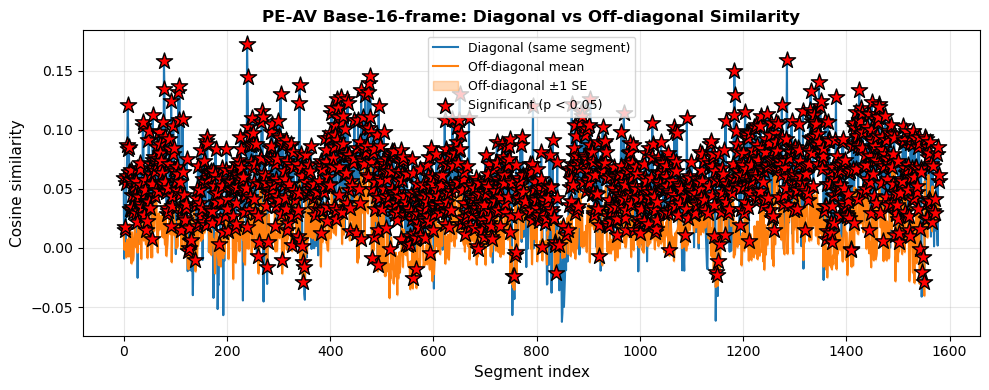

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base-16-frame/pe-av-base-16-frame_diag_analysis.png
Saved significant segments to: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base-16-frame/pe-av-base-16-frame_significant_segments.npy and /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base-16-frame/pe-av-base-16-frame_significant_segments.txt

[5/5] Computing RDMs...
Model length matches timing sum: 1581 bins
Convolving videos separately...
 
 Video 1: 106 bins convolved
 
 Video 2: 110 bins convolved
 
 Video 3: 93 bins convolved
 
 Video 4: 31 bins convolved
 
 Video 5: 41 bins convolved
 
 Video 6: 113 bins convolved
 
 Video 7: 129 bins convolved
 
 Video 8: 124 bins convolved
 
 Video 9: 41 bins convolved
 
 Video 10: 90 bins convolved
 
 Video 11: 92 bins convolved
 
 Video 12: 101 bins convolved
 
 Video 13: 70 bins convolved
 
 Video 14: 41 bins convolved
 
 Video 15: 116 bins convolved
 
 Video 

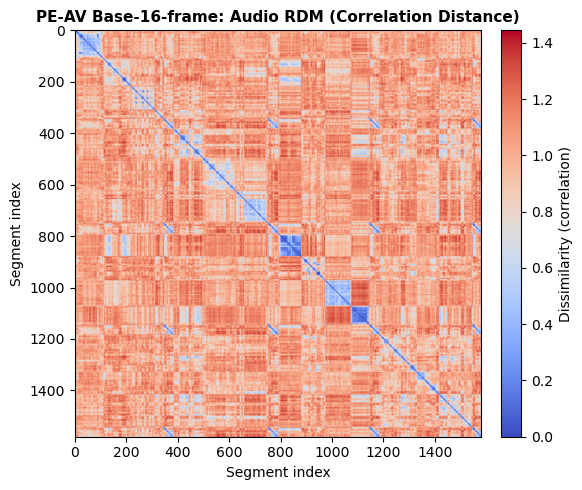

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base-16-frame/pe-av-base-16-frame_rdm_audio.png


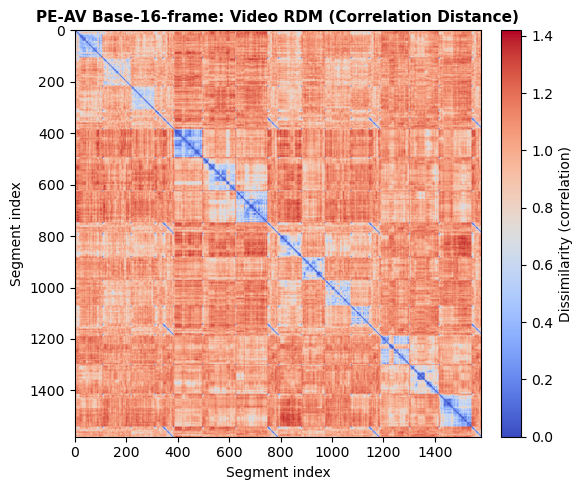

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base-16-frame/pe-av-base-16-frame_rdm_video.png


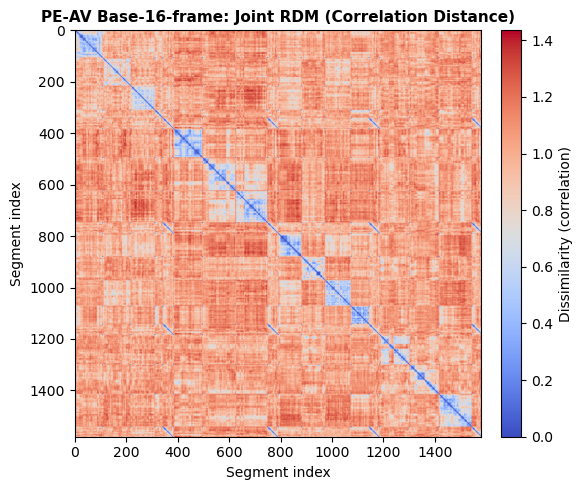

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base-16-frame/pe-av-base-16-frame_rdm_video.png

RESULTS SUMMARY FOR PE-AV Base-16-frame
Total segments: 1581
Significant segments: 1384 (87.5%)
Mean diagonal similarity: 0.051 ± 0.035
Mean off-diagonal similarity: 0.014 ± 0.019
Diagonal - Off-diagonal: 0.037

All outputs saved to: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base-16-frame


Processing: PE-AV Small
Loading: pe-av-small.npz
  Audio shape: (1581, 1024), Video shape: (1581, 1024), joint shape: (1581, 1024)

Audio embeddings: shape=(1581, 1024), mean=-0.002, std=0.076
Video embeddings: shape=(1581, 1024), mean=0.001, std=0.105
Joint embeddings: shape=(1581, 1024), mean=-0.001, std=0.101

[1/5] Computing audio-video cosine similarity...
Similarity matrix: shape=(1581, 1581), min=-0.151, max=0.193, mean=0.015
Pearson Correlation distance matrix: shape=(1581, 1581), min=0.807, max=1.151, mean=0.985

[2/5] Plotting similar

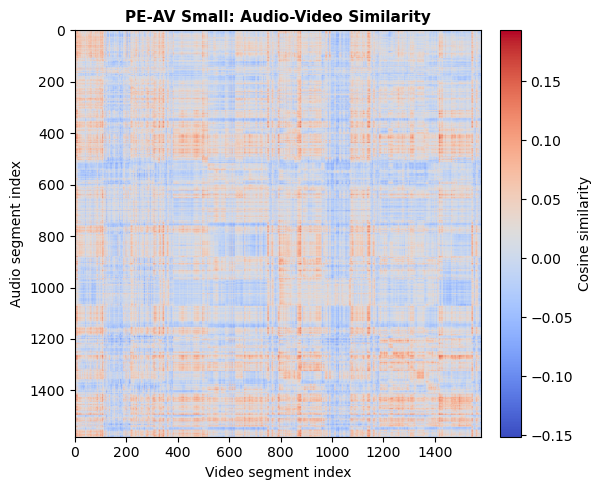

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small/pe-av-small_av_similarity.png


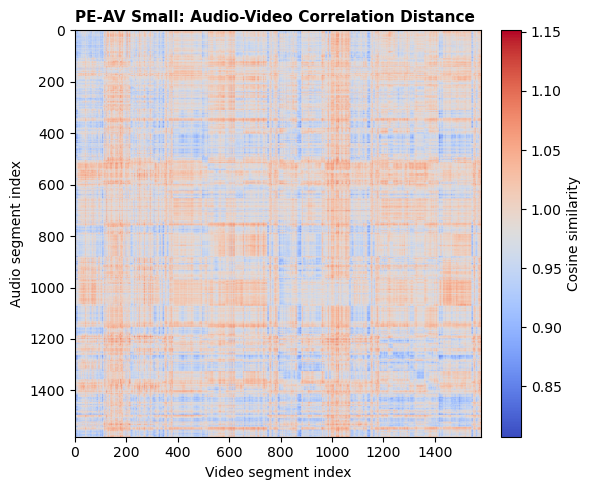


[3/5] Computing diagonal vs off-diagonal statistics...
Diagonal: mean=0.047, std=0.034
Off-diagonal: mean=0.015, std=0.019


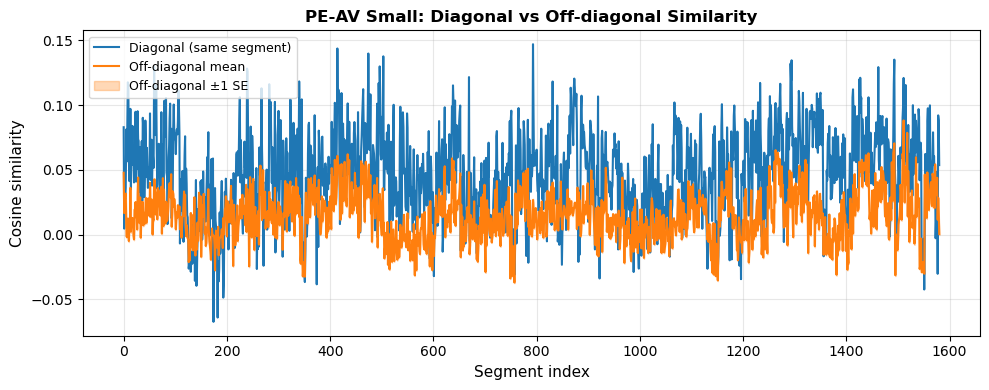

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small/pe-av-small_diag_analysis.png

[4/5] Finding significant segments (alpha=0.05)...


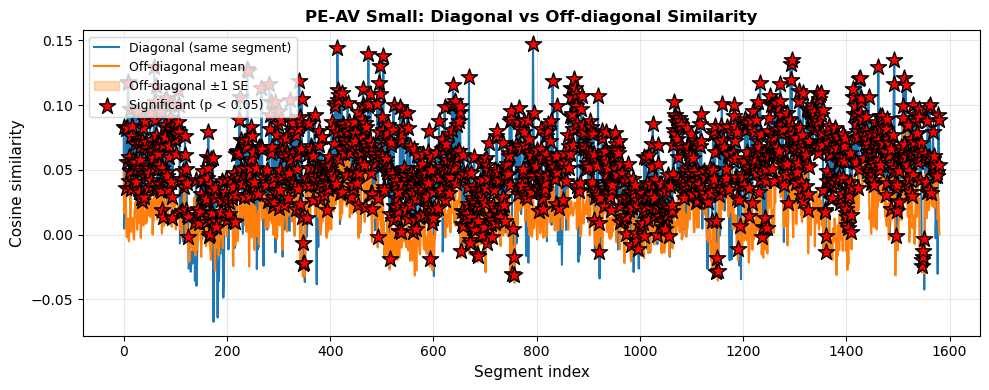

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small/pe-av-small_diag_analysis.png
Saved significant segments to: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small/pe-av-small_significant_segments.npy and /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small/pe-av-small_significant_segments.txt

[5/5] Computing RDMs...
Model length matches timing sum: 1581 bins
Convolving videos separately...
 
 Video 1: 106 bins convolved
 
 Video 2: 110 bins convolved
 
 Video 3: 93 bins convolved
 
 Video 4: 31 bins convolved
 
 Video 5: 41 bins convolved
 
 Video 6: 113 bins convolved
 
 Video 7: 129 bins convolved
 
 Video 8: 124 bins convolved
 
 Video 9: 41 bins convolved
 
 Video 10: 90 bins convolved
 
 Video 11: 92 bins convolved
 
 Video 12: 101 bins convolved
 
 Video 13: 70 bins convolved
 
 Video 14: 41 bins convolved
 
 Video 15: 116 bins convolved
 
 Video 16: 115 bins convolved
 
 Video 17: 127 bins con

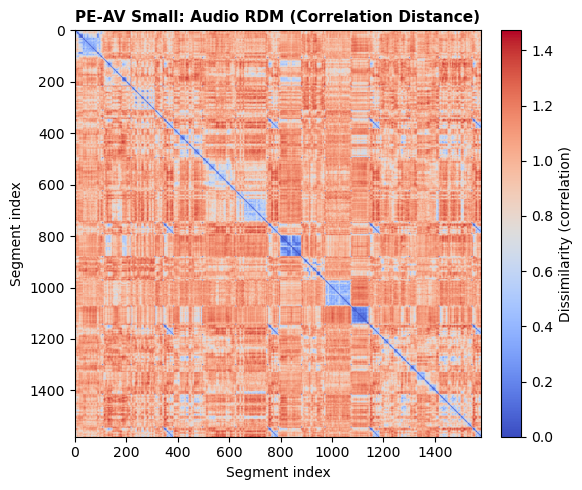

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small/pe-av-small_rdm_audio.png


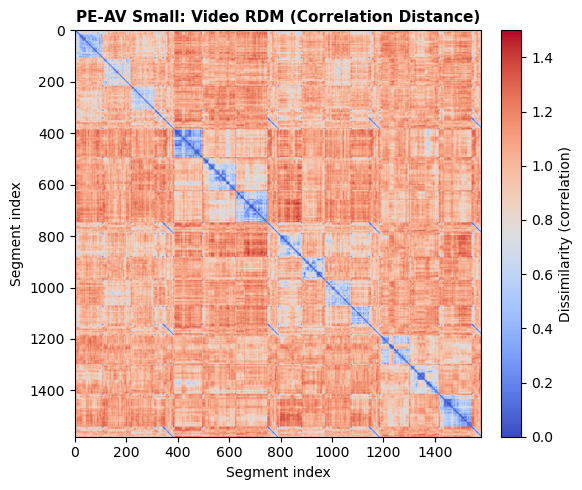

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small/pe-av-small_rdm_video.png


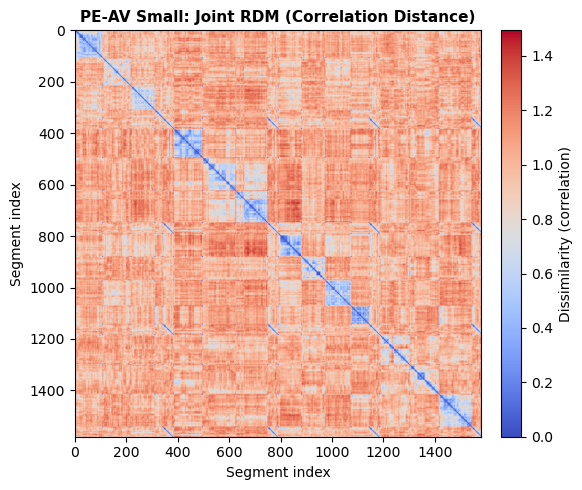

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small/pe-av-small_rdm_video.png

RESULTS SUMMARY FOR PE-AV Small
Total segments: 1581
Significant segments: 1364 (86.3%)
Mean diagonal similarity: 0.047 ± 0.034
Mean off-diagonal similarity: 0.015 ± 0.019
Diagonal - Off-diagonal: 0.032

All outputs saved to: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small


Processing: PE-AV Base
Loading: pe-av-base.npz
  Audio shape: (1581, 1024), Video shape: (1581, 1024), joint shape: (1581, 1024)

Audio embeddings: shape=(1581, 1024), mean=-0.003, std=0.074
Video embeddings: shape=(1581, 1024), mean=-0.008, std=0.117
Joint embeddings: shape=(1581, 1024), mean=-0.008, std=0.106

[1/5] Computing audio-video cosine similarity...
Similarity matrix: shape=(1581, 1581), min=-0.172, max=0.212, mean=-0.007
Pearson Correlation distance matrix: shape=(1581, 1581), min=0.789, max=1.174, mean=1.009

[2/5] Plotting similarity and correlation distance hea

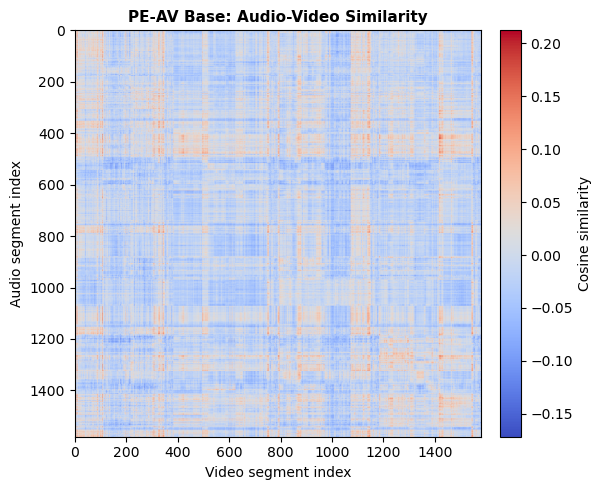

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base/pe-av-base_av_similarity.png


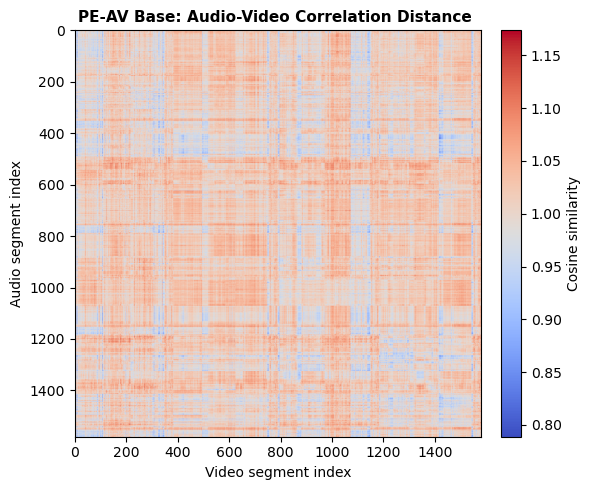


[3/5] Computing diagonal vs off-diagonal statistics...
Diagonal: mean=0.024, std=0.035
Off-diagonal: mean=-0.007, std=0.018


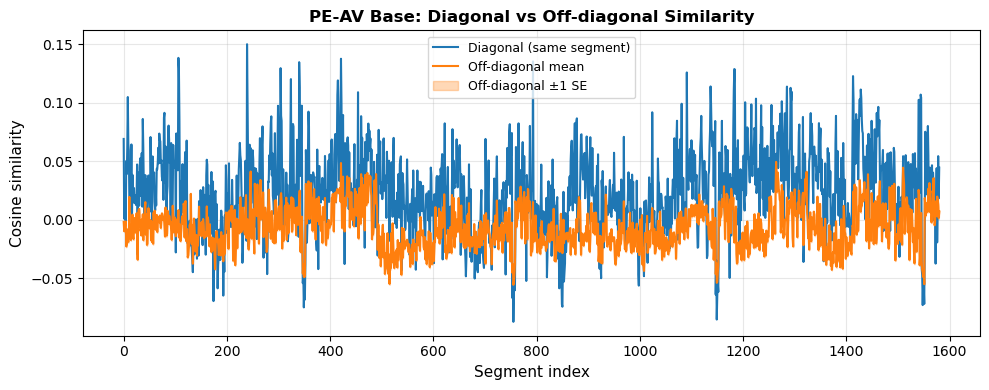

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base/pe-av-base_diag_analysis.png

[4/5] Finding significant segments (alpha=0.05)...


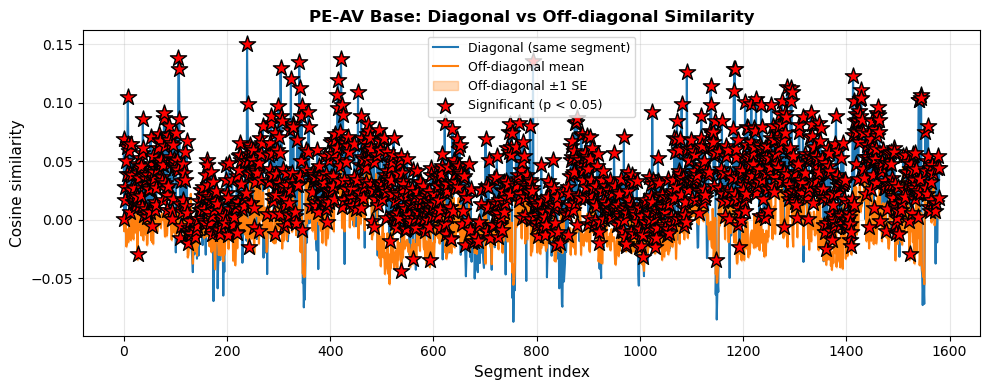

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base/pe-av-base_diag_analysis.png
Saved significant segments to: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base/pe-av-base_significant_segments.npy and /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base/pe-av-base_significant_segments.txt

[5/5] Computing RDMs...
Model length matches timing sum: 1581 bins
Convolving videos separately...
 
 Video 1: 106 bins convolved
 
 Video 2: 110 bins convolved
 
 Video 3: 93 bins convolved
 
 Video 4: 31 bins convolved
 
 Video 5: 41 bins convolved
 
 Video 6: 113 bins convolved
 
 Video 7: 129 bins convolved
 
 Video 8: 124 bins convolved
 
 Video 9: 41 bins convolved
 
 Video 10: 90 bins convolved
 
 Video 11: 92 bins convolved
 
 Video 12: 101 bins convolved
 
 Video 13: 70 bins convolved
 
 Video 14: 41 bins convolved
 
 Video 15: 116 bins convolved
 
 Video 16: 115 bins convolved
 
 Video 17: 127 bins convolved

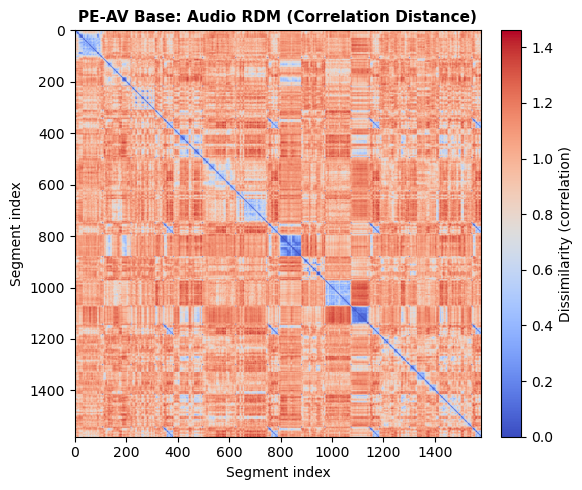

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base/pe-av-base_rdm_audio.png


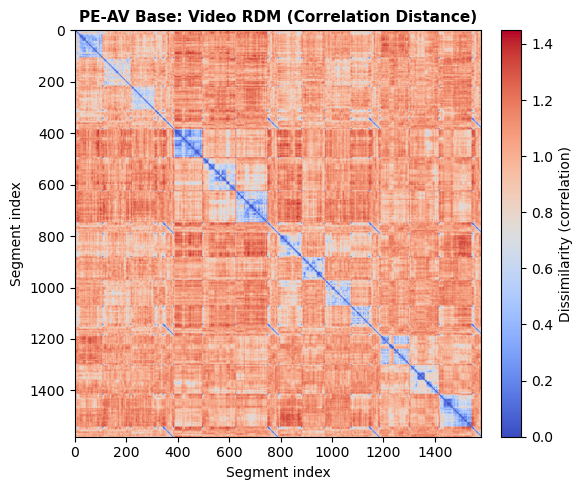

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base/pe-av-base_rdm_video.png


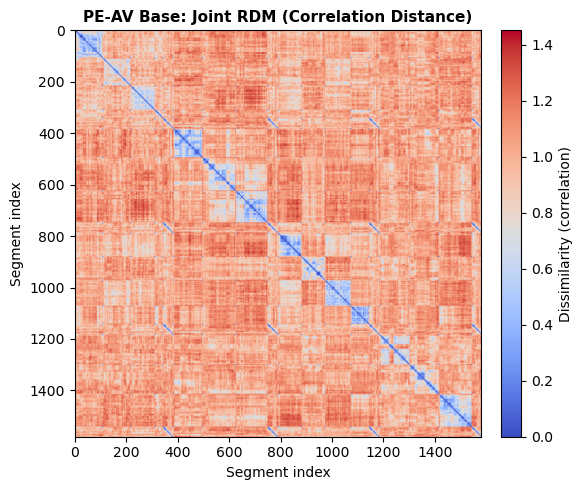

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base/pe-av-base_rdm_video.png

RESULTS SUMMARY FOR PE-AV Base
Total segments: 1581
Significant segments: 1317 (83.3%)
Mean diagonal similarity: 0.024 ± 0.035
Mean off-diagonal similarity: -0.007 ± 0.018
Diagonal - Off-diagonal: 0.031

All outputs saved to: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-base


Processing: PE-AV Large
Loading: pe-av-large.npz
  Audio shape: (1581, 1024), Video shape: (1581, 1024), joint shape: (1581, 1024)

Audio embeddings: shape=(1581, 1024), mean=0.003, std=0.080
Video embeddings: shape=(1581, 1024), mean=0.003, std=0.107
Joint embeddings: shape=(1581, 1024), mean=0.004, std=0.112

[1/5] Computing audio-video cosine similarity...
Similarity matrix: shape=(1581, 1581), min=-0.152, max=0.233, mean=0.013
Pearson Correlation distance matrix: shape=(1581, 1581), min=0.768, max=1.154, mean=0.988

[2/5] Plotting similarity and correlation distance heatmaps

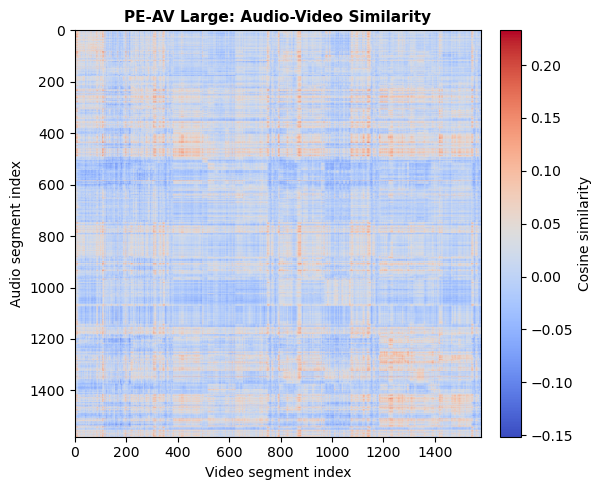

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large/pe-av-large_av_similarity.png


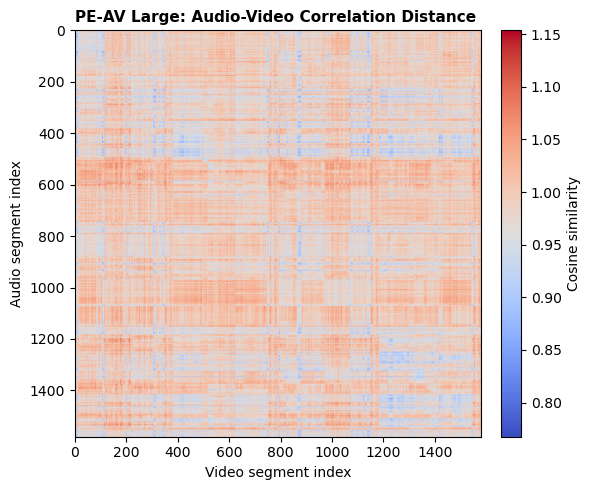


[3/5] Computing diagonal vs off-diagonal statistics...
Diagonal: mean=0.046, std=0.035
Off-diagonal: mean=0.013, std=0.023


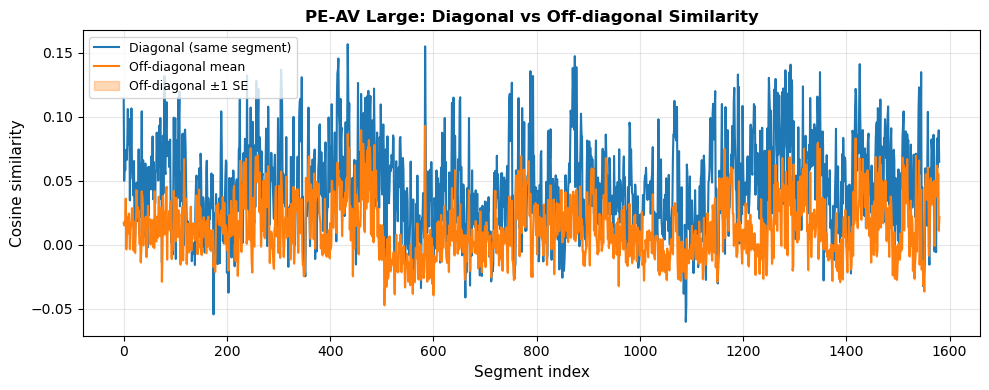

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large/pe-av-large_diag_analysis.png

[4/5] Finding significant segments (alpha=0.05)...


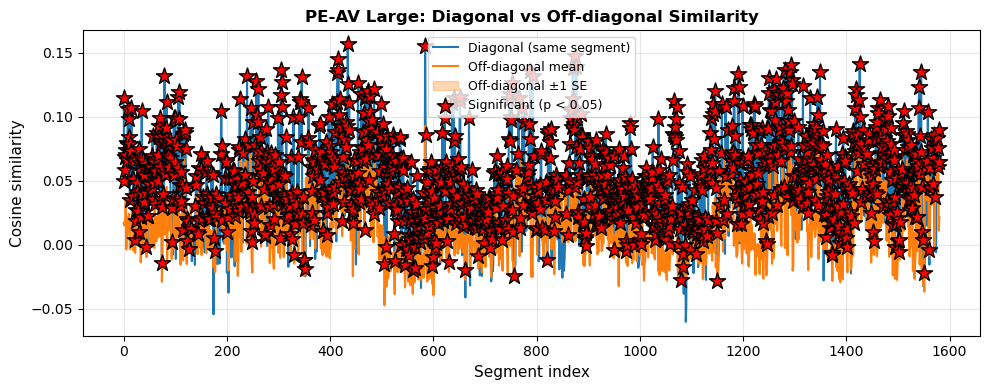

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large/pe-av-large_diag_analysis.png
Saved significant segments to: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large/pe-av-large_significant_segments.npy and /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large/pe-av-large_significant_segments.txt

[5/5] Computing RDMs...
Model length matches timing sum: 1581 bins
Convolving videos separately...
 
 Video 1: 106 bins convolved
 
 Video 2: 110 bins convolved
 
 Video 3: 93 bins convolved
 
 Video 4: 31 bins convolved
 
 Video 5: 41 bins convolved
 
 Video 6: 113 bins convolved
 
 Video 7: 129 bins convolved
 
 Video 8: 124 bins convolved
 
 Video 9: 41 bins convolved
 
 Video 10: 90 bins convolved
 
 Video 11: 92 bins convolved
 
 Video 12: 101 bins convolved
 
 Video 13: 70 bins convolved
 
 Video 14: 41 bins convolved
 
 Video 15: 116 bins convolved
 
 Video 16: 115 bins convolved
 
 Video 17: 127 bins con

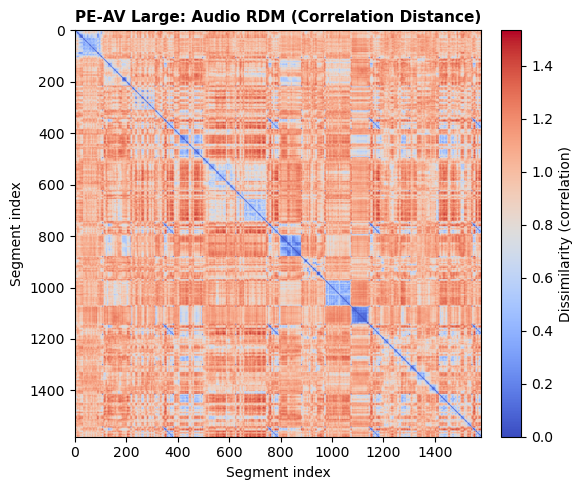

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large/pe-av-large_rdm_audio.png


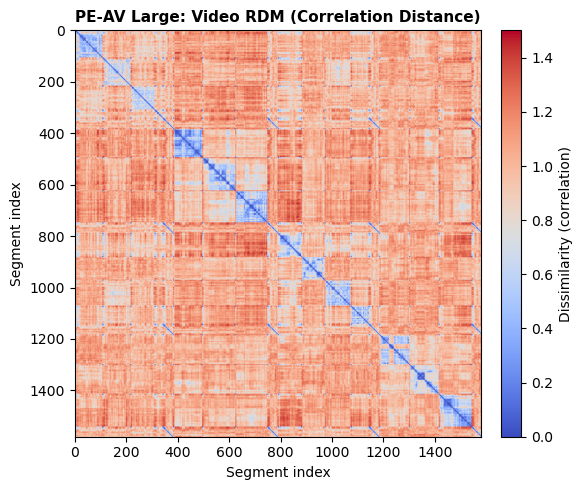

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large/pe-av-large_rdm_video.png


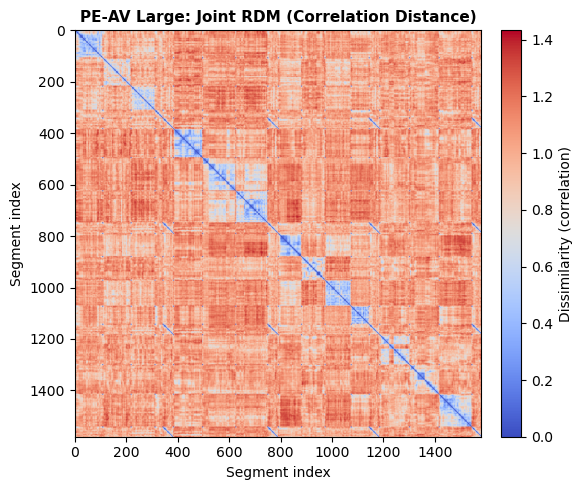

Saved: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large/pe-av-large_rdm_video.png

RESULTS SUMMARY FOR PE-AV Large
Total segments: 1581
Significant segments: 1359 (86.0%)
Mean diagonal similarity: 0.046 ± 0.035
Mean off-diagonal similarity: 0.013 ± 0.023
Diagonal - Off-diagonal: 0.032

All outputs saved to: /home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-large



In [12]:
# Compute RDMs, similarity matrices, and significance analysis for each PE-AV run
for run in PEAV_RUNS:
    print(f"\n{'='*70}")
    print(f"Processing: {run['model_name']}")
    print(f"{'='*70}")
    
    # Load embeddings
    audio, video, joint = load_modality_embeddings(run["emb_dir"])
    out_dir = run["emb_dir"]
    out_dir.mkdir(parents=True, exist_ok=True)
    
    label = run['label']
    model_name = run['model_name']
    alpha = 0.05
    
    # Print embedding statistics
    print(f"\nAudio embeddings: shape={audio.shape}, "
          f"mean={audio.mean():.3f}, std={audio.std():.3f}")
    print(f"Video embeddings: shape={video.shape}, "
          f"mean={video.mean():.3f}, std={video.std():.3f}")
    print(f"Joint embeddings: shape={joint.shape}, "
          f"mean={joint.mean():.3f}, std={joint.std():.3f}")

    # ========== 1. COMPUTE AUDIO-VIDEO COSINE SIMILARITY ==========
    print("\n[1/5] Computing audio-video cosine similarity...")
    sim = cosine_similarity(audio, video)
    corr_dist = cdist(audio, video, metric='correlation')

    print(f"Similarity matrix: shape={sim.shape}, "
          f"min={sim.min():.3f}, max={sim.max():.3f}, mean={sim.mean():.3f}")
    
    print(f"Pearson Correlation distance matrix: shape={corr_dist.shape}, "
          f"min={corr_dist.min():.3f}, max={corr_dist.max():.3f}, mean={corr_dist.mean():.3f}")
    
    
    # Save similarity matrix
    np.save(out_dir / f"{label}_av_similarity.npy", sim.astype(np.float32))
    
    # ========== 2. PLOT SIMILARITY HEATMAPS ==========
    print("\n[2/5] Plotting similarity and correlation distance heatmaps...")
    plot_av_similarity_heatmap(
        sim,
        out_dir / f"{label}_av_similarity.png",
        f"{model_name}: Audio-Video Similarity",
    )
    plot_av_similarity_heatmap(
        corr_dist,
        out_dir / f"{label}_av_similarity.png",
        f"{model_name}: Audio-Video Correlation Distance ",
    )
    
    # ========== 3. COMPUTE DIAGONAL STATISTICS ==========
    print("\n[3/5] Computing diagonal vs off-diagonal statistics...")
    diag, off_mean, off_se = compute_diag_stats(sim)
    
    print(f"Diagonal: mean={diag.mean():.3f}, std={diag.std():.3f}")
    print(f"Off-diagonal: mean={off_mean.mean():.3f}, std={off_mean.std():.3f}")
    sig_indices = None
    plot_diag_stats(
        diag,
        off_mean,
        off_se,
        sig_indices,
        out_dir / f"{label}_diag_analysis.png",
        f"{model_name}: Diagonal vs Off-diagonal Similarity",
        alpha=alpha
    )
    
    # ========== 4. FIND SIGNIFICANT SEGMENTS & PLOT ==========
    print(f"\n[4/5] Finding significant segments (alpha={alpha})...")
    sig_indices = find_significant_segments(sim, alpha=alpha)
    
    # Plot diagonal analysis with significance markers
    plot_diag_stats(
        diag,
        off_mean,
        off_se,
        sig_indices,
        out_dir / f"{label}_diag_analysis.png",
        f"{model_name}: Diagonal vs Off-diagonal Similarity",
        alpha=alpha
    )
    
    # Save significant segments
    sig_path_npy = out_dir / f"{label}_significant_segments.npy"
    sig_path_txt = out_dir / f"{label}_significant_segments.txt"
    
    np.save(sig_path_npy, np.array(sig_indices, dtype=np.int64))
    
    with open(sig_path_txt, "w") as f:
        f.write(f"# Significant segments (diag > off-diag, p < {alpha})\n")
        f.write(f"# Total: {len(sig_indices)} / {len(diag)} segments\n")
        f.write(f"# Segment indices (0-based):\n")
        f.write(",".join(str(idx) for idx in sig_indices))
    print(f"Saved significant segments to: {sig_path_npy} and {sig_path_txt}")
    # ========== 5. COMPUTE RDMs (Correlation Distance) ==========
    print("\n[5/5] Computing RDMs...")
    
    rdm_audio = compute_rdm(audio, metric="correlation")
    rdm_video = compute_rdm(video, metric="correlation")
    rdm_joint = compute_rdm(joint, metric="correlation")

    
    # Save RDMs
    np.save(out_dir / f"{label}_rdm_audio.npy", rdm_audio.astype(np.float32))
    np.save(out_dir / f"{label}_rdm_video.npy", rdm_video.astype(np.float32))
    
    # Plot RDMs
    plot_rdm(
        rdm_audio,
        out_dir / f"{label}_rdm_audio.png",
        f"{model_name}: Audio RDM (Correlation Distance)",
        metric="correlation",
    )
    
    plot_rdm(
        rdm_video,
        out_dir / f"{label}_rdm_video.png",
        f"{model_name}: Video RDM (Correlation Distance)",
        metric="correlation",
    )
    plot_rdm(
        rdm_joint,
        out_dir / f"{label}_rdm_video.png",
        f"{model_name}: Joint RDM (Correlation Distance)",
        metric="correlation",
    )
    
    # ========== SUMMARY ==========
    print(f"\n{'='*70}")
    print(f"RESULTS SUMMARY FOR {model_name}")
    print(f"{'='*70}")
    print(f"Total segments: {len(diag)}")
    print(f"Significant segments: {len(sig_indices)} ({100*len(sig_indices)/len(diag):.1f}%)")
    print(f"Mean diagonal similarity: {diag.mean():.3f} ± {diag.std():.3f}")
    print(f"Mean off-diagonal similarity: {off_mean.mean():.3f} ± {off_mean.std():.3f}")
    print(f"Diagonal - Off-diagonal: {(diag.mean() - off_mean.mean()):.3f}")
    print(f"\nAll outputs saved to: {out_dir}")
    print(f"{'='*70}\n")